# 🔹 UNSUPERVISED LEARNING (K-MEANS CLUSTERING)

In [7]:
# ======================================
# 1. Import Required Libraries
# ======================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


# ======================================
# 2. Load Dataset
# ======================================
df = pd.read_csv("Loan_default.csv")


# ======================================
# 3. Remove Target Column (Unsupervised)
# ======================================
if "Default" in df.columns:
    df_unsup = df.drop("Default", axis=1)
else:
    df_unsup = df.copy()


# ======================================
# 4. Remove Non-Numeric (ID/Text) Columns
# ======================================
df_unsup = df_unsup.select_dtypes(include=["int64", "float64"])


# ======================================
# 5. Feature Scaling
# ======================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_unsup)


# ======================================
# 6. Apply K-Means Clustering
# ======================================
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df_unsup["Cluster"] = clusters


# ======================================
# 7. Dimensionality Reduction (PCA for Visualization)
# ======================================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_unsup["PCA1"] = X_pca[:, 0]
df_unsup["PCA2"] = X_pca[:, 1]


print(df_unsup["PCA1"])
print("===============================================================")
print(df_unsup["PCA2"])

0        -0.779353
1        -0.842676
2        -1.084232
3        -1.545713
4        -1.161898
            ...   
255342    2.366847
255343   -0.655053
255344    0.649090
255345   -0.577726
255346   -1.369572
Name: PCA1, Length: 255347, dtype: float64
0         0.139465
1        -0.642905
2        -0.251151
3        -1.044230
4        -1.665788
            ...   
255342    0.020738
255343   -0.383530
255344   -0.188598
255345   -1.041750
255346    0.565809
Name: PCA2, Length: 255347, dtype: float64


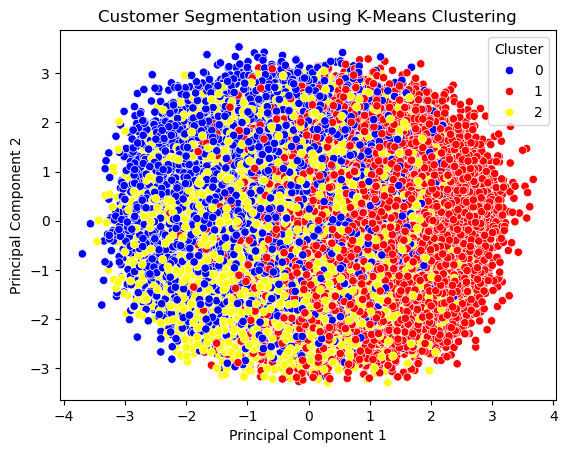

In [11]:
sns.scatterplot(
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    data=df_unsup,
    palette=["blue", "red", "yellow"]
)

plt.title("Customer Segmentation using K-Means Clustering")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()